In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/metadata.csv
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2580.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2617.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2794.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2696.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2585.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2637.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/validation/RG/EyePACS-TRAIN-RG-2537.jpg
/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import timm
import torch.optim as optim
from tqdm import tqdm

In [3]:
# Define Augmentation Transformations
transform = transforms.Compose([
    transforms.RandomResizedCrop((224, 224), scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(15),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])

In [4]:
# Load EyePACS Dataset
data_dir = "/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg"
# Update train, validation, and test datasets with transforms
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=transform)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/validation", transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=f"{data_dir}/test", transform=val_test_transform)

In [5]:
# Create Data Loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [6]:
# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
# Function to count images and classes in a dataset
def dataset_stats(dataset, dataset_name):
    num_images = len(dataset)
    class_counts = {}
    for _, label in dataset:
        class_name = dataset.classes[label]
        if class_name not in class_counts:
            class_counts[class_name] = 0
        class_counts[class_name] += 1

    print(f"Dataset: {dataset_name}")
    print(f"Total Images: {num_images}")
    print("Class Counts:")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count}")
    print()

# Check stats for each dataset
dataset_stats(train_dataset, "Train")
dataset_stats(val_dataset, "Validation")
dataset_stats(test_dataset, "Test")


Dataset: Train
Total Images: 8000
Class Counts:
  NRG: 4000
  RG: 4000

Dataset: Validation
Total Images: 770
Class Counts:
  NRG: 385
  RG: 385

Dataset: Test
Total Images: 770
Class Counts:
  NRG: 385
  RG: 385



In [8]:
# Load Vision Transformer (ViT) Model
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=2)
model = model.to(device)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [9]:
class ViTWithDropout(nn.Module):
    def __init__(self, base_model, dropout_rate=0.5):
        super(ViTWithDropout, self).__init__()
        self.base_model = base_model
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(base_model.embed_dim, 2)  # Use embed_dim for input features

    def forward(self, x):
        x = self.base_model.forward_features(x)  # Shape: [batch_size, seq_len, embed_dim]
        cls_token = x[:, 0, :]  # Select [CLS] token (first token in sequence)
        cls_token = self.dropout(cls_token)  # Apply dropout to [CLS] token
        x = self.classifier(cls_token)  # Shape: [batch_size, num_classes]
        return x

# Wrap the ViT model with dropout
dropout_rate = 0.5
model_with_dropout = ViTWithDropout(model, dropout_rate).to(device)

In [10]:
model = model_with_dropout

In [11]:
# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [12]:
print(model)

ViTWithDropout(
  (base_model): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate=

In [13]:
for images, labels in train_loader:
    images = images.to(device)
    outputs = model_with_dropout(images)
    print(f"Output shape: {outputs.shape}") 
    break

Output shape: torch.Size([32, 2])


In [14]:
for images, labels in train_loader:
    print(f"Label shape: {labels.shape}")  
    break


Label shape: torch.Size([32])


In [15]:
import torch

# Inspect model features and shapes
def inspect_model_features(model, input_shape=(1, 3, 224, 224)):
    model.eval()  # Set model to evaluation mode
    dummy_input = torch.randn(*input_shape)  # Create a dummy input tensor
    dummy_input = dummy_input.to(next(model.parameters()).device)  # Ensure it's on the correct device

    hooks = []

    # Hook function to capture the output of each layer
    def hook_fn(module, input, output):
        print(f"{module.__class__.__name__} - Output Shape: {output.shape}")

    # Register hooks to each module
    for name, module in model.named_modules():
        if isinstance(module, (nn.Linear, nn.Conv2d, nn.LayerNorm)):  # You can customize which layers to inspect
            hooks.append(module.register_forward_hook(hook_fn))

    # Perform a forward pass with dummy input
    print("Inspecting model features and shapes...")
    with torch.no_grad():
        _ = model(dummy_input)

    # Remove hooks after inspection
    for hook in hooks:
        hook.remove()

# Check features of the Vision Transformer
inspect_model_features(model, input_shape=(1, 3, 224, 224))


Inspecting model features and shapes...
Conv2d - Output Shape: torch.Size([1, 768, 14, 14])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 2304])
Linear - Output Shape: torch.Size([1, 197, 768])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 3072])
Linear - Output Shape: torch.Size([1, 197, 768])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 2304])
Linear - Output Shape: torch.Size([1, 197, 768])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 3072])
Linear - Output Shape: torch.Size([1, 197, 768])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 2304])
Linear - Output Shape: torch.Size([1, 197, 768])
LayerNorm - Output Shape: torch.Size([1, 197, 768])
Linear - Output Shape: torch.Size([1, 197, 3072])
Linear - Output Shape: torch.Size([1, 197, 768])
La

In [ ]:
# Training Function with Accuracy and Loss Logging
def train(model, train_loader, val_loader, epochs=10):
    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            progress_bar.set_postfix(loss=running_loss / total, acc=100.0 * correct / total)

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        val_acc, val_loss = validate(model, val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model, "best_vit_model.pth")

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # Save final model
    torch.save(model, "final_vit_model.pth")
    print("Final model saved as final_vit_model.pth")

    return train_losses, val_losses, train_accuracies, val_accuracies

# Validation Function
def validate(model, val_loader):
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100.0 * correct / total
    return val_acc, val_loss

train_losses, val_losses, train_accuracies, val_accuracies = train(model, train_loader, val_loader, epochs=10)


Epoch 1/10: 100%|██████████| 250/250 [02:30<00:00,  1.66it/s, acc=78.3, loss=0.0145]


Epoch 1: Train Loss=0.4643, Train Acc=78.26%, Val Loss=0.3430, Val Acc=84.81%


Epoch 2/10: 100%|██████████| 250/250 [02:31<00:00,  1.66it/s, acc=87, loss=0.00963]  


Epoch 2: Train Loss=0.3081, Train Acc=87.04%, Val Loss=0.2385, Val Acc=90.65%


Epoch 3/10: 100%|██████████| 250/250 [02:31<00:00,  1.65it/s, acc=89.3, loss=0.00841]


...

Epoch 8: Train Loss=0.1339, Train Acc=94.80%, Val Loss=0.1702, Val Acc=93.51%


Epoch 9/10: 100%|██████████| 250/250 [02:31<00:00,  1.65it/s, acc=94.9, loss=0.00392]


Epoch 9: Train Loss=0.1254, Train Acc=94.91%, Val Loss=0.1613, Val Acc=93.51%


Epoch 10/10: 100%|██████████| 250/250 [02:31<00:00,  1.65it/s, acc=95.7, loss=0.00356]


Epoch 10: Train Loss=0.1141, Train Acc=95.71%, Val Loss=0.1885, Val Acc=92.99%
Final model saved as final_vit_model.pth


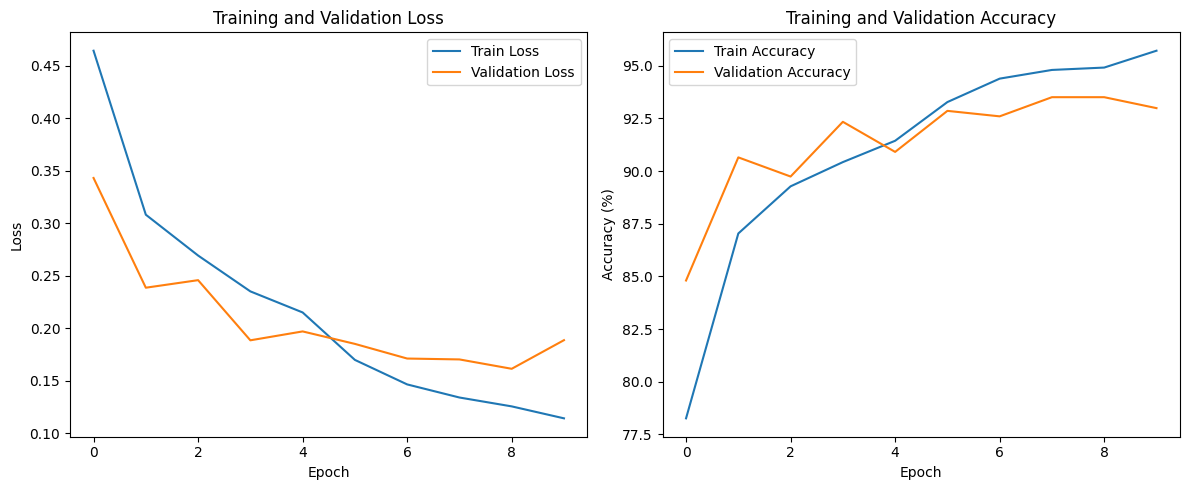

In [21]:
import matplotlib.pyplot as plt
# Plot Training and Validation Metrics
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [23]:
# Test Function
def test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    test_acc = 100.0 * correct / total
    print(f"Test Accuracy: {test_acc:.2f}%")
    return all_labels, all_preds

# Load the entire model
model_path = "/kaggle/working/best_vit_model.pth"  # Path to the saved model
loaded_model = torch.load(model_path)  # Load the entire model
loaded_model = loaded_model.to(device)  # Move to the correct device

# Test the loaded model
labels, preds = test(loaded_model, test_loader)

<ipython-input-23-8676003f36f3>:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(model_path)  # Load the entire model
Testing: 100%|██████████| 25

Test Accuracy: 92.47%


Classification Report:

              precision    recall  f1-score   support

         NRG       0.95      0.90      0.92       385
          RG       0.90      0.95      0.93       385

    accuracy                           0.92       770
   macro avg       0.93      0.92      0.92       770
weighted avg       0.93      0.92      0.92       770



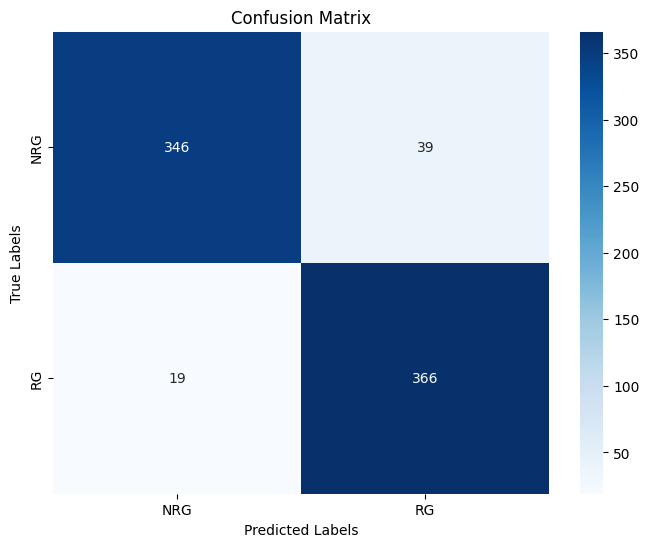

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
# Generate Classification Report and Confusion Matrix
def generate_reports(labels, preds, class_names):
    print("Classification Report:\n")
    print(classification_report(labels, preds, target_names=class_names))

    conf_matrix = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


# Generate reports
class_names = test_dataset.classes
generate_reports(labels, preds, class_names)

In [25]:
from PIL import Image
import numpy as np

# Function to Test Model on Custom Images
def test_on_custom_images(model, image_paths, class_names):
    model.eval()

    for image_path in image_paths:
        image = Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, predicted = output.max(1)

        print(f"Image: {image_path} | Predicted Class: {class_names[predicted.item()]}")


# Test on Custom Images
custom_image_paths = ["/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/NRG/EyePACS-TRAIN-NRG-2890.jpg", "/kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/RG/EyePACS-TRAIN-RG-2891.jpg"]
test_on_custom_images(model, custom_image_paths, class_names)

Image: /kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/NRG/EyePACS-TRAIN-NRG-2890.jpg | Predicted Class: NRG
Image: /kaggle/input/glaucoma-dataset-eyepacs-airogs-light-v2/eyepac-light-v2-512-jpg/test/RG/EyePACS-TRAIN-RG-2891.jpg | Predicted Class: RG
